In [1]:
# gelu: https://arxiv.org/abs/1606.08415 
import apple

In [2]:
gelu=apple.jit('''
{ gelu ← λx. 
  { ncdf ← λz.
    { erf ← λz.
      { facts ⟜ (*) Λₒ 1 (frange 1 50 50)
      ; Hoa ← λN.λa. {xs ← gen. z [_1*x*(z^2)] (N+1); (+)/ₒ 0 ((%)`xs (a'⍳N))}
      ; (2%√𝜋)*Hoa 50 (λn. (facts˙n*(2*ℝn+1)))
      };
      zz ⟜ z%√2;
      0.5*(1+erf(zz))
    };
    x*ncdf(x)
  };
(gelu')
}
''')

In [3]:
gelu_tanh=apple.jit('''
{ gelu ← λx. 
  { tanh ← [(e:(2*x)-1)%(e:(2*x)+1)]
  ; ½*x*(1+tanh (√(2%𝜋)*(x+0.044715*x^3)))
  }
; (gelu')
}
''')

In [4]:
import matplotlib.pyplot as plt

In [5]:
import numpy as np

In [6]:
xs=np.arange(-5,5,0.001,dtype=np.float64)

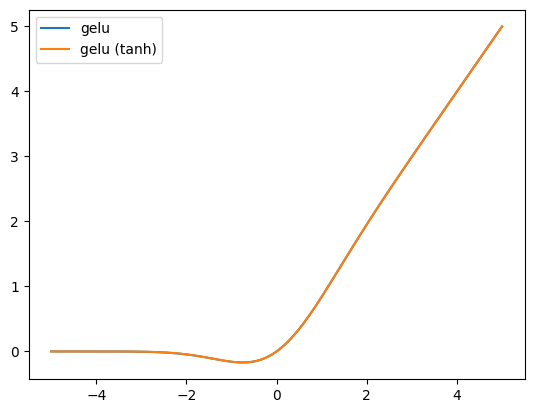

In [7]:
plt.plot(xs,gelu(xs),label='gelu')
plt.plot(xs,gelu_tanh(xs),label='gelu (tanh)')
plt.legend();plt.show()